# Guests by frequency for `btw25`

With our data from lanz-mining, we can use jupyter to build some simple scripts and explore the obtained data. 
Further we can show the background and make the process a little more transparent (at least for people with some coding knowledge).

Here we a more narrow time range from the coalition breaking (06.11.24) until 02.02.25. The objective is to find out 
who is invited in which frequency. It's assumed we find correlations to the topic distributions.

In [16]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from datetime import date, datetime
from pathlib import Path

from lanz_mining import params
from lanz_mining.dataproc import text
from lanz_mining.projects.utils import get_all_basic_frames, df_to_time_range

In [9]:
lanz_df, illner_df, miosga_df = get_all_basic_frames(["date", "name", "talkshow"], "../../")
lanz_df.shape, illner_df.shape, miosga_df.shape

((1358, 4), (190, 4), (100, 4))

In [18]:
maisch_df = params.TALKSHOWS["maischberger"]["processor"](
    Path("../../exports/export-maisch.csv")
).dataframe.rename({"maischepisode_name": "episode_name"})
maisch_df = maisch_df["episode_name", "date", "name", "talkshow"]
print(maisch_df)
all_df: pl.DataFrame = pl.concat([lanz_df, illner_df, miosga_df, maisch_df], how="vertical")
start = date(2024, 11, 6)
latest = all_df["date"].max()
all_df = df_to_time_range(all_df, start, datetime.today())

start, latest

shape: (414, 4)
┌────────────────────────────┬─────────────────────┬───────────────────────┬──────────────┐
│ episode_name               ┆ date                ┆ name                  ┆ talkshow     │
│ ---                        ┆ ---                 ┆ ---                   ┆ ---          │
│ str                        ┆ datetime[μs]        ┆ str                   ┆ str          │
╞════════════════════════════╪═════════════════════╪═══════════════════════╪══════════════╡
│ maischberger am 17.12.2024 ┆ 2024-12-17 00:00:00 ┆ Sebastian Kurz        ┆ maischberger │
│ maischberger am 17.12.2024 ┆ 2024-12-17 00:00:00 ┆ Hendrik Wüst          ┆ maischberger │
│ maischberger am 17.12.2024 ┆ 2024-12-17 00:00:00 ┆ Gregor Peter Schmitz  ┆ maischberger │
│ maischberger am 17.12.2024 ┆ 2024-12-17 00:00:00 ┆ Theo Koll             ┆ maischberger │
│ maischberger am 17.12.2024 ┆ 2024-12-17 00:00:00 ┆ Ann-Kathrin Hipp      ┆ maischberger │
│ …                          ┆ …                   ┆ …          

(datetime.date(2024, 11, 6), datetime.datetime(2025, 2, 2, 0, 0))

In [24]:
# See how many people were invited two times
invited2 = all_df["name"].value_counts(sort=True, name="invites").filter(pl.col("invites").eq(2))
invited2.shape, ", ".join(invited2["name"].to_list())

((38, 2),
 "Saskia Esken, Antje Höning, Martin Machowecz, Frederik Pleitgen, Karl Lauterbach, Katharina Dröge, Hubertus Heil, Veit Medick, Katrin Göring-Eckardt, Sonja Álvarez, Kristin Helberg, Jens Spahn, Daniel Gerlach, Felix Banaszak, Wolfram Weimer, Sigmar Gabriel, Markus Feldenkirchen, Manfred Weber, Ulrike Herrmann, Beatrix von Storch, John Bolton, Alexander Dobrindt, Ricarda Lang, Carsten Linnemann, Friedrich Merz, Giovanni di Lorenzo, Hendrik Wüst, Annalena Baerbock, Christian Lindner, Armin Laschet, Claudia Major, Albrecht von Lucke, Alice Weidel, Theo Koll, Sahra Wagenknecht, Jan Fleischhauer, Yasmine M'Barek, Markus Söder")

During the this phase of btw25 (6.11.24 - 2.2.25) we can observe how radical right wing politicians like "Alice Weidel" and "Beatrix von Storch" are equally often aired on public service media as "Saskia Esken", "Friedrich Merz" or "Ricarda Lang". Which speaks for the normalisation of AfD as a party, despite the antidemoratic vibe they produce.

In [26]:
df_by_invites = all_df["name"].value_counts(sort=True, name="invites").top_k(25, by="invites")
df_by_invites

name,invites
str,u32
"""Elmar Theveßen""",6
"""Robert Habeck""",5
"""Robin Alexander""",5
"""Christian Dürr""",4
"""Helene Bubrowski""",4
…,…
"""Frederik Pleitgen""",2
"""Karl Lauterbach""",2
"""Katharina Dröge""",2


In [27]:
talkshow2invites = {}
for talkshow_name, df in all_df.group_by("talkshow"):
    invites = []
    for name in df_by_invites["name"]:
        n = df.filter(pl.col("name").eq(name)).shape[0]
        invites.append(n)
    talkshow2invites[talkshow_name[0]] = invites

talkshow2color = {
    "markuslanz": "#EA580C",
    "maybritillner": "#F472B6",
    "carenmiosga": "#14B8A6",
    "maischberger": "#6D28D9",
}
proper_labels = {
    "markuslanz": "Markus Lanz",
    "maybritillner": "Maybrit Illner",
    "carenmiosga": "Caren Miosga",
    "maischberger": "Maischberger",
}
y_labels = df_by_invites["name"].to_numpy()
", ".join(y_labels)

'Elmar Theveßen, Robert Habeck, Robin Alexander, Christian Dürr, Helene Bubrowski, Michael Bröcker, Thorsten Frei, Melanie Amann, Kerstin Münstermann, Peer Steinbrück, Lars Klingbeil, Carlo Masala, Nikolaus Blome, Gerald Knaus, Eva Quadbeck, Kristina Dunz, Wolfgang Ischinger, Saskia Esken, Antje Höning, Martin Machowecz, Frederik Pleitgen, Karl Lauterbach, Katharina Dröge, Hubertus Heil, Veit Medick'

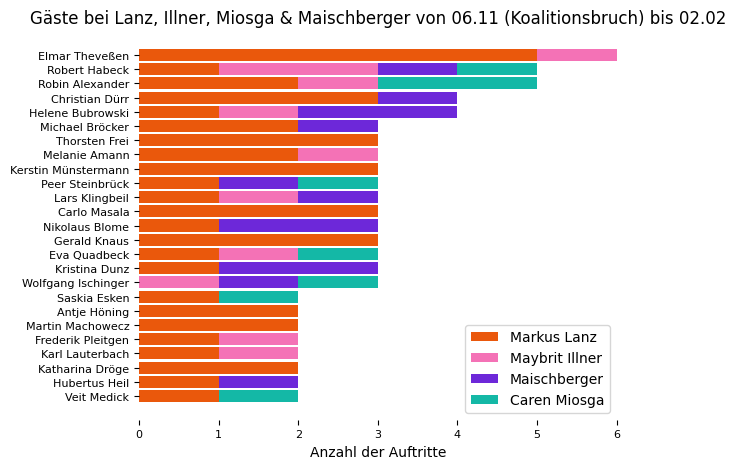

In [29]:
bar_start = np.zeros(len(y_labels))
width = 0.85
fig, ax = plt.subplots()
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.spines.left.set_visible(False)
ax.spines.bottom.set_visible(False)
title = f"Gäste bei Lanz, Illner, Miosga & Maischberger von {start.strftime('%d.%m')} (Koalitionsbruch) bis {latest.strftime('%d.%m')}"
ax.set_title(title)
for talkshow_name in ["markuslanz", "maybritillner", "maischberger", "carenmiosga"]:
    sequence = talkshow2invites[talkshow_name]
    ax.barh(
        y_labels,
        sequence,
        width,
        label=proper_labels[talkshow_name],
        left=bar_start,
        color=talkshow2color[talkshow_name],
    )
    bar_start += sequence

ax.invert_yaxis()
ax.tick_params(axis="both", which="major", labelsize=8)
ax.set_yticks(np.arange(len(y_labels)), labels=y_labels)
ax.set_xlabel("Anzahl der Auftritte")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()